# Vision Offset Dataset EDA

DataCollect2가 저장한 `vision_offset_dataset`만 분석한다.

관심 대상:
- 입력 이미지: `images/left`, `images/center`, `images/right`
- 학습 label: TF 기준 `label.plug_tip_to_port.{x,y,z,xy}`
- 수집 분포: `collect.pattern`, `collect.radius_m`, `collect.local_x_m`, `collect.local_y_m`
- 보조 품질 정보: YOLO camera별 confidence / detection 여부, triangulation valid 여부

이 노트북은 LeRobot parquet, insertion phase, raw video decoding을 사용하지 않는다.


In [14]:
from pathlib import Path
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except Exception:
    display = print

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

In [17]:
# 기본 경로는 DataCollect2의 기본 저장 위치와 맞춘다.
# DataCollect2는 AIC_LEROBOT_OUT_DIR이 상대경로이면 실행 cwd 기준으로 저장한다.
# auto_capture를 프로젝트 루트에서 실행하는 흐름에 맞춰 기본 cwd를 AIC_Sejong root로 둔다.
PROJECT_ROOT = Path('/home/vsc/LLM_TUNE/AIC_Sejong')
WS_ROOT = PROJECT_ROOT / 'ws_aic'
DEFAULT_LEROBOT_OUT = Path(os.environ.get('AIC_LEROBOT_ENTRANCE_DIR', 'lerobot')).expanduser()
DEFAULT_VERSION = os.environ.get('AIC_LEROBOT_VERSION', 'v1.0')

explicit_dataset_dir = os.environ.get('AIC_VISION_OFFSET_DATASET_DIR', '').strip()
if explicit_dataset_dir:
    VISION_DATASET_DIR = Path(explicit_dataset_dir).expanduser()
else:
    VISION_DATASET_DIR = DEFAULT_LEROBOT_OUT / DEFAULT_VERSION / 'vision_offset_dataset'

if not VISION_DATASET_DIR.is_absolute():
    VISION_DATASET_DIR = (PROJECT_ROOT / VISION_DATASET_DIR).resolve()

SAMPLES_JSONL = VISION_DATASET_DIR / 'samples.jsonl'
OUT_DIR = Path(os.environ.get(
    'AIC_EDA_OUT_DIR',
    str(WS_ROOT / 'src/ais/ais_eda/eda_outputs/vision_offset_dataset')
)).expanduser()
if not OUT_DIR.is_absolute():
    OUT_DIR = (PROJECT_ROOT / OUT_DIR).resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT       :', PROJECT_ROOT)
print('VISION_DATASET_DIR:', VISION_DATASET_DIR)
print('SAMPLES_JSONL      :', SAMPLES_JSONL)
print('OUT_DIR            :', OUT_DIR)


PROJECT_ROOT       : /home/vsc/LLM_TUNE/AIC_Sejong
VISION_DATASET_DIR: /home/vsc/LLM_TUNE/AIC_Sejong/ws_aic/src/data/lerobot_entrance/v1.0/vision_offset_dataset
SAMPLES_JSONL      : /home/vsc/LLM_TUNE/AIC_Sejong/ws_aic/src/data/lerobot_entrance/v1.0/vision_offset_dataset/samples.jsonl
OUT_DIR            : /home/vsc/LLM_TUNE/AIC_Sejong/ws_aic/src/ais/ais_eda/eda_outputs/vision_offset_dataset


In [18]:
def flatten_record(rec):
    label = rec.get('label', {}).get('plug_tip_to_port', {})
    collect = rec.get('collect', {})
    tri = rec.get('triangulation', {})
    yolo = rec.get('yolo', {})
    cameras = yolo.get('cameras', {})
    images = rec.get('images', {})

    row = {
        'sample_id': rec.get('sample_id', ''),
        'episode_name': rec.get('episode_name', ''),
        'task_id': rec.get('task_id', ''),
        'task_type': rec.get('task_type', ''),
        'port_type': rec.get('port_type', ''),
        'port_name': rec.get('port_name', ''),
        'target_module_name': rec.get('target_module_name', ''),
        'phase': rec.get('phase', ''),
        'step_index': rec.get('step_index', -1),
        'x_m': label.get('x_m', np.nan),
        'y_m': label.get('y_m', np.nan),
        'z_m': label.get('z_m', np.nan),
        'xy_m': label.get('xy_m', np.nan),
        'x_mm': label.get('x_mm', np.nan),
        'y_mm': label.get('y_mm', np.nan),
        'z_mm': label.get('z_mm', np.nan),
        'xy_mm': label.get('xy_mm', np.nan),
        'collect_pattern': collect.get('pattern', ''),
        'collect_radius_mm': collect.get('radius_m', np.nan) * 1000.0,
        'collect_theta_rad': collect.get('theta_rad', np.nan),
        'collect_local_x_mm': collect.get('local_x_m', np.nan) * 1000.0,
        'collect_local_y_mm': collect.get('local_y_m', np.nan) * 1000.0,
        'triangulation_valid': bool(tri.get('valid', False)),
        'triangulated_x_mm': tri.get('x_m', np.nan) * 1000.0,
        'triangulated_y_mm': tri.get('y_m', np.nan) * 1000.0,
        'triangulated_z_mm': tri.get('z_m', np.nan) * 1000.0,
        'triangulated_xy_mm': tri.get('xy_m', np.nan) * 1000.0,
        'triangulated_port_views': tri.get('port_views', 0),
        'triangulated_port_pairs': tri.get('port_pairs', 0),
        'yolo_selected_camera': yolo.get('selected_camera', ''),
        'yolo_multiview_detect_count': yolo.get('multiview_detect_count', 0),
    }
    for cam in ['left', 'center', 'right']:
        cam_det = cameras.get(cam, {})
        rel_path = images.get(cam, '')
        abs_path = VISION_DATASET_DIR / rel_path if rel_path else Path('')
        row[f'{cam}_image'] = rel_path
        row[f'{cam}_image_exists'] = bool(rel_path and abs_path.exists())
        row[f'{cam}_detected'] = bool(cam_det.get('detected', False))
        row[f'{cam}_confidence'] = float(cam_det.get('confidence', 0.0)) if cam_det.get('detected', False) else 0.0
        row[f'{cam}_center_x'] = float(cam_det.get('center_x', np.nan)) if cam_det.get('detected', False) else np.nan
        row[f'{cam}_center_y'] = float(cam_det.get('center_y', np.nan)) if cam_det.get('detected', False) else np.nan
        row[f'{cam}_area_ratio'] = float(cam_det.get('area_ratio', 0.0)) if cam_det.get('detected', False) else 0.0
    return row

if not SAMPLES_JSONL.exists():
    raise FileNotFoundError(f'samples.jsonl not found: {SAMPLES_JSONL}')

records = []
with SAMPLES_JSONL.open('r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(flatten_record(json.loads(line)))

df = pd.DataFrame(records)
for col in ['x_mm', 'y_mm', 'z_mm', 'xy_mm', 'collect_radius_mm', 'collect_local_x_mm', 'collect_local_y_mm']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Loaded samples: {len(df):,}')
display(df.head())


Loaded samples: 1,120


,sample_id,episode_name,task_id,task_type,port_type,port_name,target_module_name,phase,step_index,x_m,...,center_center_x,center_center_y,center_area_ratio,right_image,right_image_exists,right_detected,right_confidence,right_center_x,right_center_y,right_area_ratio
0,20260506_181642_nic_rail0_sfp_port_0_task_1_co...,20260506_181642_nic_rail0_sfp_port_0_task_1,nic_rail0_sfp_port_0_task_1,nic,sfp,sfp_port_0,nic_card_mount_0,collect,0,0.005616,...,582.680664,556.485291,0.002045,images/right/20260506_181642_nic_rail0_sfp_por...,True,False,0.0,NaN,NaN,0.0
1,20260506_181642_nic_rail0_sfp_port_0_task_1_co...,20260506_181642_nic_rail0_sfp_port_0_task_1,nic_rail0_sfp_port_0_task_1,nic,sfp,sfp_port_0,nic_card_mount_0,collect,1,0.004821,...,582.680664,556.485291,0.002045,images/right/20260506_181642_nic_rail0_sfp_por...,True,False,0.0,NaN,NaN,0.0
2,20260506_181642_nic_rail0_sfp_port_0_task_1_co...,20260506_181642_nic_rail0_sfp_port_0_task_1,nic_rail0_sfp_port_0_task_1,nic,sfp,sfp_port_0,nic_card_mount_0,collect,2,0.003604,...,582.680664,556.485291,0.002045,images/right/20260506_181642_nic_rail0_sfp_por...,True,False,0.0,NaN,NaN,0.0
3,20260506_181642_nic_rail0_sfp_port_0_task_1_co...,20260506_181642_nic_rail0_sfp_port_0_task_1,nic_rail0_sfp_port_0_task_1,nic,sfp,sfp_port_0,nic_card_mount_0,collect,3,0.002576,...,582.680664,556.485291,0.002045,images/right/20260506_181642_nic_rail0_sfp_por...,True,False,0.0,NaN,NaN,0.0
4,20260506_181642_nic_rail0_sfp_port_0_task_1_co...,20260506_181642_nic_rail0_sfp_port_0_task_1,nic_rail0_sfp_port_0_task_1,nic,sfp,sfp_port_0,nic_card_mount_0,collect,4,0.001176,...,582.680664,556.485291,0.002045,images/right/20260506_181642_nic_rail0_sfp_por...,True,False,0.0,NaN,NaN,0.0


In [19]:
# Dataset 구성 요약
summary_rows = []
summary_rows.append({'metric': 'samples', 'value': len(df)})
summary_rows.append({'metric': 'episodes', 'value': df['episode_name'].nunique()})
summary_rows.append({'metric': 'tasks', 'value': df['task_id'].nunique()})
summary_rows.append({'metric': 'collect_patterns', 'value': ', '.join(map(str, sorted(df['collect_pattern'].dropna().unique())))})
for cam in ['left', 'center', 'right']:
    summary_rows.append({'metric': f'{cam}_image_exists_pct', 'value': df[f'{cam}_image_exists'].mean() * 100.0})
    summary_rows.append({'metric': f'{cam}_detected_pct', 'value': df[f'{cam}_detected'].mean() * 100.0})

summary = pd.DataFrame(summary_rows)
display(summary)

by_task_port = df.groupby(['task_type', 'port_name'], dropna=False).agg(
    n=('sample_id', 'count'),
    episodes=('episode_name', 'nunique'),
    x_mean_mm=('x_mm', 'mean'),
    y_mean_mm=('y_mm', 'mean'),
    xy_mean_mm=('xy_mm', 'mean'),
    xy_p95_mm=('xy_mm', lambda s: s.quantile(0.95)),
).reset_index()
display(by_task_port.round(3))

summary.to_csv(OUT_DIR / 'vision_dataset_summary.csv', index=False)
by_task_port.to_csv(OUT_DIR / 'vision_dataset_by_task_port.csv', index=False)


,metric,value
0,samples,1120
1,episodes,7
2,tasks,7
3,collect_patterns,gaussian
4,left_image_exists_pct,100.0
5,left_detected_pct,63.839286
6,center_image_exists_pct,100.0
7,center_detected_pct,70.357143
8,right_image_exists_pct,100.0
9,right_detected_pct,8.035714


,task_type,port_name,n,episodes,x_mean_mm,y_mean_mm,xy_mean_mm,xy_p95_mm
0,nic,sfp_port_0,480,3,-0.084,0.108,3.006,6.401
1,nic,sfp_port_1,320,2,-0.107,0.042,3.407,6.624
2,sc,sc_port_base,320,2,0.499,0.206,2.735,5.127


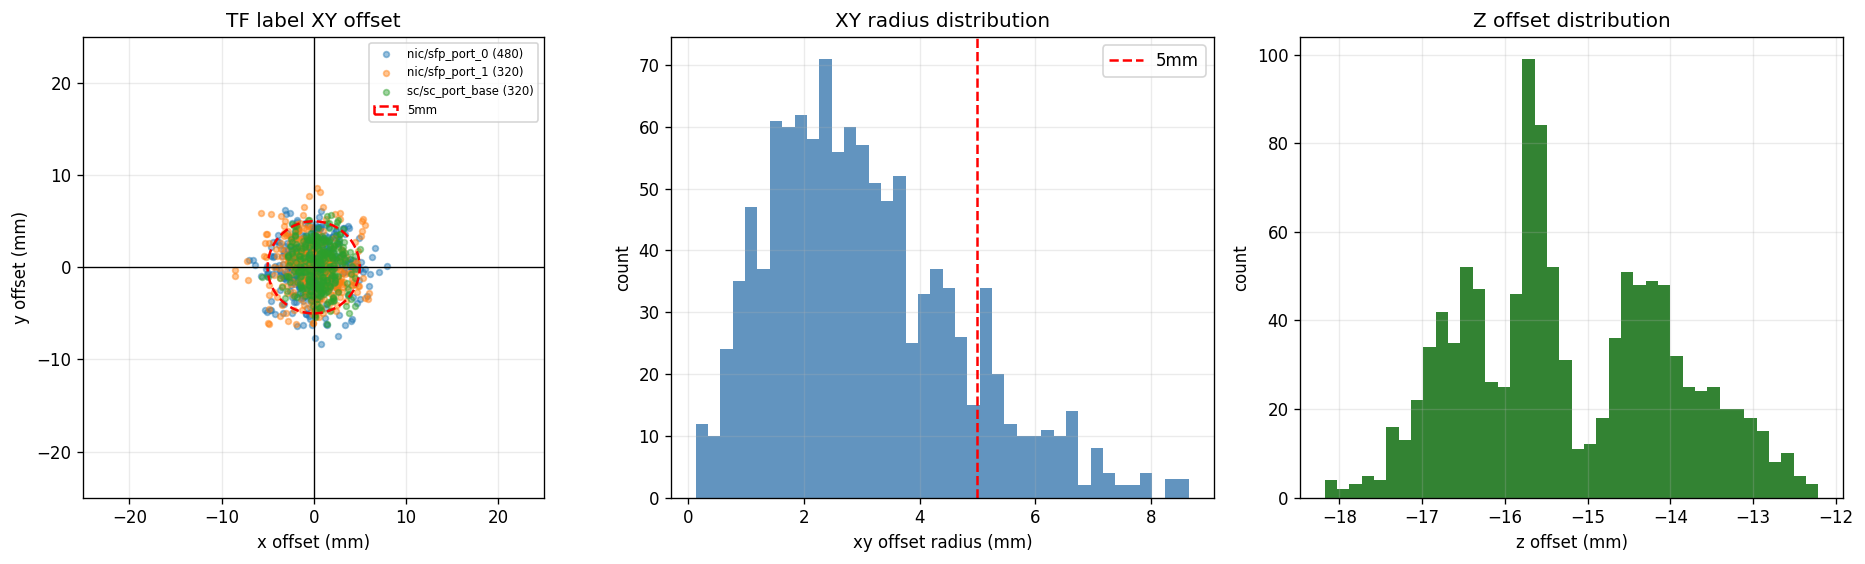

,x_mm,y_mm,z_mm,xy_mm
count,1120.000,1120.000,1120.000,1120.000
mean,0.076,0.117,-15.224,3.043
std,2.301,2.573,1.248,1.632
min,-8.530,-8.320,-18.178,0.131
1%,-5.321,-6.093,-17.640,0.343
5%,-3.648,-4.422,-17.058,0.832
50%,0.074,0.124,-15.493,2.792
95%,4.061,4.280,-13.085,6.275
99%,5.518,5.805,-12.608,7.599
max,7.967,8.662,-12.212,8.668


In [20]:
# Label 분포: 모델이 맞춰야 할 plug-tip-to-port offset
XY_LIMIT_MM = float(os.environ.get('AIC_EDA_XY_LIMIT_MM', '25'))
OK_RADIUS_MM = float(os.environ.get('AIC_EDA_OK_RADIUS_MM', '5'))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

ax = axes[0]
for (task, port), sub in df.groupby(['task_type', 'port_name'], dropna=False):
    ax.scatter(sub['x_mm'], sub['y_mm'], s=12, alpha=0.45, label=f'{task}/{port} ({len(sub)})')
circle = plt.Circle((0, 0), OK_RADIUS_MM, fill=False, color='red', ls='--', lw=1.5, label=f'{OK_RADIUS_MM:.0f}mm')
ax.add_patch(circle)
ax.axhline(0, color='black', lw=0.8)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlim(-XY_LIMIT_MM, XY_LIMIT_MM)
ax.set_ylim(-XY_LIMIT_MM, XY_LIMIT_MM)
ax.set_aspect('equal', adjustable='box')
ax.set_title('TF label XY offset')
ax.set_xlabel('x offset (mm)')
ax.set_ylabel('y offset (mm)')
ax.legend(fontsize=7)

axes[1].hist(df['xy_mm'].dropna(), bins=40, color='steelblue', alpha=0.85)
axes[1].axvline(OK_RADIUS_MM, color='red', ls='--', lw=1.5, label=f'{OK_RADIUS_MM:.0f}mm')
axes[1].set_title('XY radius distribution')
axes[1].set_xlabel('xy offset radius (mm)')
axes[1].set_ylabel('count')
axes[1].legend()

axes[2].hist(df['z_mm'].dropna(), bins=40, color='darkgreen', alpha=0.8)
axes[2].set_title('Z offset distribution')
axes[2].set_xlabel('z offset (mm)')
axes[2].set_ylabel('count')

plt.tight_layout()
fig.savefig(OUT_DIR / 'label_offset_distribution.png', dpi=180)
plt.show()

display(df[['x_mm', 'y_mm', 'z_mm', 'xy_mm']].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).round(3))


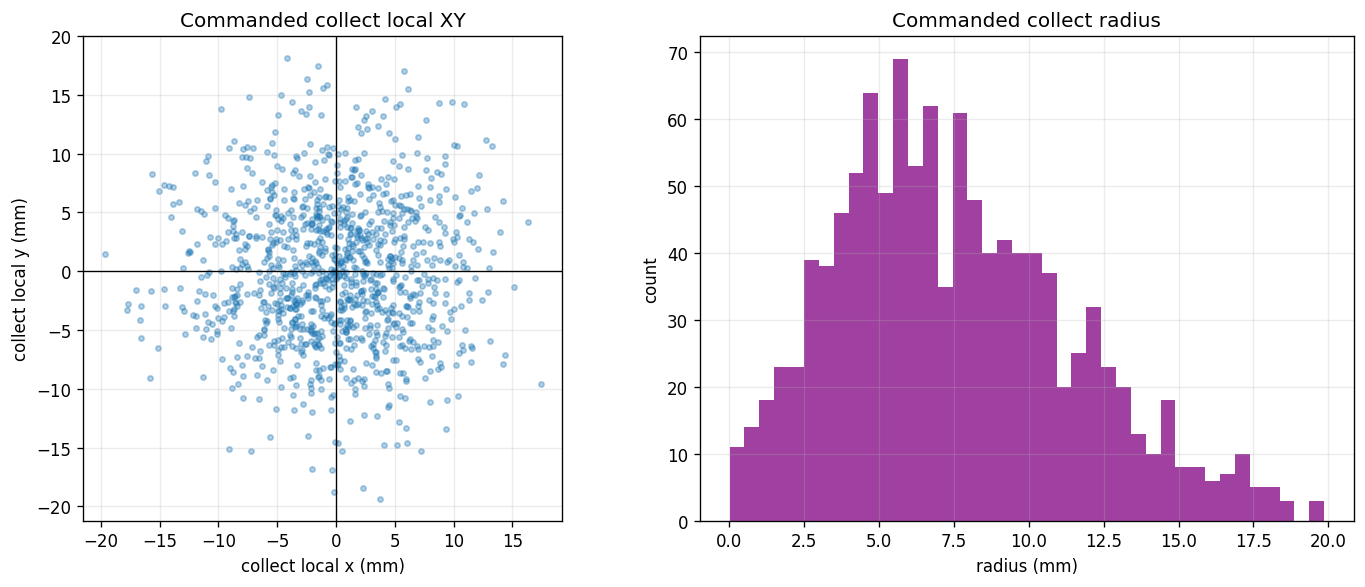

,collect_pattern,collect_local_x_mm,collect_local_y_mm,collect_radius_mm
count,1120,1120.000,1120.000,1120.000
unique,1,NaN,NaN,NaN
top,gaussian,NaN,NaN,NaN
freq,1120,NaN,NaN,NaN
mean,NaN,-0.145,-0.041,7.546
std,NaN,6.027,6.029,3.963
min,NaN,-19.643,-19.338,0.013
25%,NaN,-3.931,-4.241,4.625
50%,NaN,-0.020,-0.245,6.952
75%,NaN,4.042,4.188,10.094


In [21]:
# COLLECT 명령 분포: gaussian이면 0mm 근처가 가장 조밀해야 한다.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(df['collect_local_x_mm'], df['collect_local_y_mm'], s=10, alpha=0.35)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_aspect('equal', adjustable='box')
axes[0].set_title('Commanded collect local XY')
axes[0].set_xlabel('collect local x (mm)')
axes[0].set_ylabel('collect local y (mm)')

axes[1].hist(df['collect_radius_mm'].dropna(), bins=40, color='purple', alpha=0.75)
axes[1].set_title('Commanded collect radius')
axes[1].set_xlabel('radius (mm)')
axes[1].set_ylabel('count')

plt.tight_layout()
fig.savefig(OUT_DIR / 'collect_command_distribution.png', dpi=180)
plt.show()

display(df[['collect_pattern', 'collect_local_x_mm', 'collect_local_y_mm', 'collect_radius_mm']].describe(include='all').round(3))


,camera,n,image_exists_pct,detected_pct,conf_mean,conf_p10,conf_p50,conf_p90,area_mean
0,left,1120,100.0,63.839,0.557,0.0,0.869,0.890,0.002
1,center,1120,100.0,70.357,0.594,0.0,0.839,0.878,0.002
2,right,1120,100.0,8.036,0.062,0.0,0.000,0.000,0.000


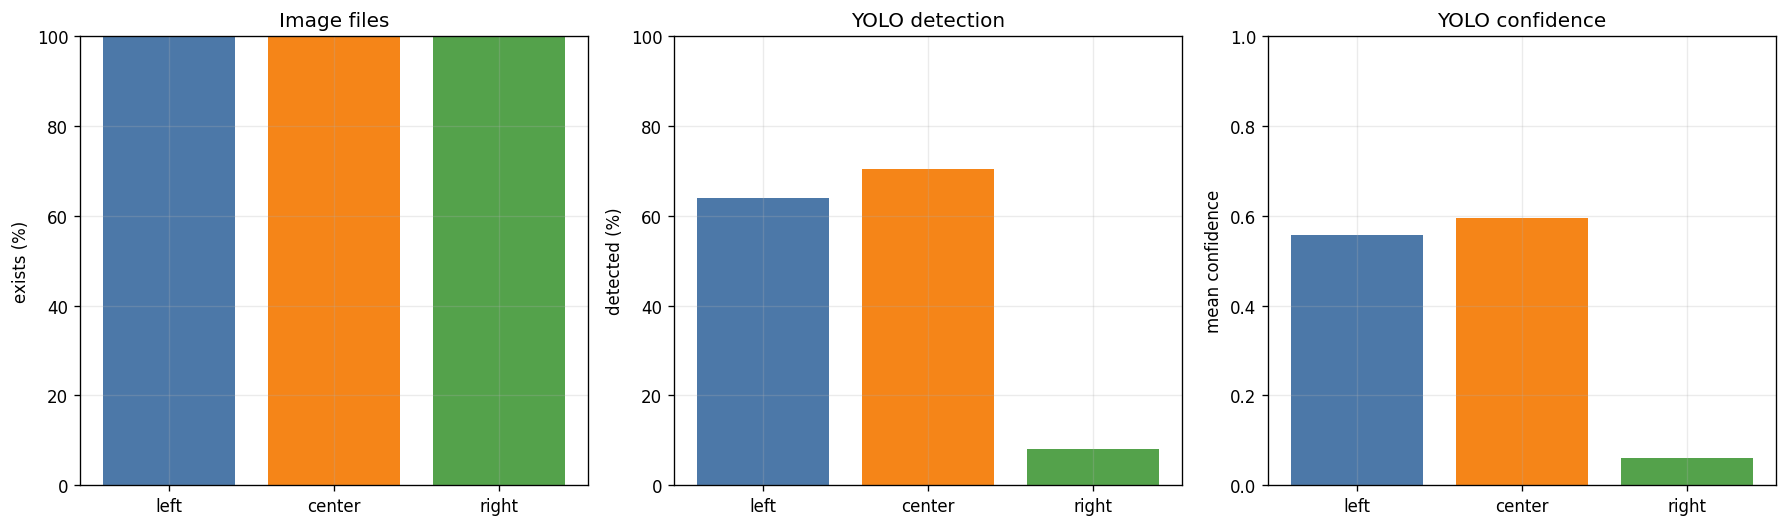

In [22]:
# Camera별 이미지 존재율 / YOLO 검출률 / confidence
cam_rows = []
for cam in ['left', 'center', 'right']:
    cam_rows.append({
        'camera': cam,
        'n': len(df),
        'image_exists_pct': df[f'{cam}_image_exists'].mean() * 100.0,
        'detected_pct': df[f'{cam}_detected'].mean() * 100.0,
        'conf_mean': df[f'{cam}_confidence'].mean(),
        'conf_p10': df[f'{cam}_confidence'].quantile(0.10),
        'conf_p50': df[f'{cam}_confidence'].quantile(0.50),
        'conf_p90': df[f'{cam}_confidence'].quantile(0.90),
        'area_mean': df[f'{cam}_area_ratio'].mean(),
    })
cam_summary = pd.DataFrame(cam_rows)
display(cam_summary.round(3))
cam_summary.to_csv(OUT_DIR / 'camera_quality_summary.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, metric, title, ylabel in [
    (axes[0], 'image_exists_pct', 'Image files', 'exists (%)'),
    (axes[1], 'detected_pct', 'YOLO detection', 'detected (%)'),
    (axes[2], 'conf_mean', 'YOLO confidence', 'mean confidence'),
]:
    ax.bar(cam_summary['camera'], cam_summary[metric], color=['#4C78A8', '#F58518', '#54A24B'])
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 100 if metric.endswith('_pct') else max(1.0, cam_summary[metric].max() * 1.2))
plt.tight_layout()
fig.savefig(OUT_DIR / 'camera_quality_bars.png', dpi=180)
plt.show()


Triangulation valid: 708/1,120 (63.2%)


,tri_minus_tf_x_mm,tri_minus_tf_y_mm,tri_minus_tf_z_mm,tri_minus_tf_xy_mm
count,708.000,708.000,708.000,708.000
mean,3.346,-0.138,33.699,24.844
std,14.920,21.243,30.451,8.186
min,-34.409,-41.755,-9.703,1.782
25%,-3.607,-23.691,-1.367,21.367
50%,3.656,2.151,32.430,25.862
75%,14.028,20.592,72.949,30.019
max,29.714,38.188,83.654,42.365


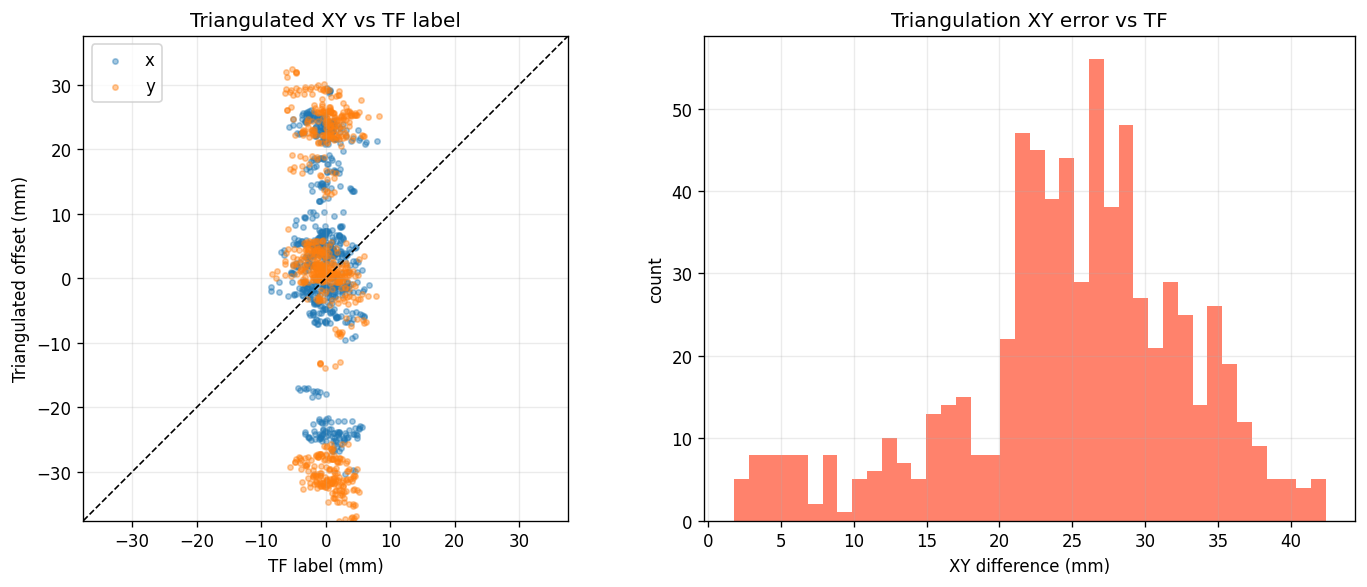

In [23]:
# Triangulation 보조값과 TF label 차이 확인
tri_df = df[df['triangulation_valid']].copy()
print(f'Triangulation valid: {len(tri_df):,}/{len(df):,} ({len(tri_df)/max(len(df),1)*100:.1f}%)')

if len(tri_df):
    tri_df['tri_minus_tf_x_mm'] = tri_df['triangulated_x_mm'] - tri_df['x_mm']
    tri_df['tri_minus_tf_y_mm'] = tri_df['triangulated_y_mm'] - tri_df['y_mm']
    tri_df['tri_minus_tf_z_mm'] = tri_df['triangulated_z_mm'] - tri_df['z_mm']
    tri_df['tri_minus_tf_xy_mm'] = np.sqrt(tri_df['tri_minus_tf_x_mm']**2 + tri_df['tri_minus_tf_y_mm']**2)
    display(tri_df[['tri_minus_tf_x_mm', 'tri_minus_tf_y_mm', 'tri_minus_tf_z_mm', 'tri_minus_tf_xy_mm']].describe().round(3))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].scatter(tri_df['x_mm'], tri_df['triangulated_x_mm'], s=10, alpha=0.4, label='x')
    axes[0].scatter(tri_df['y_mm'], tri_df['triangulated_y_mm'], s=10, alpha=0.4, label='y')
    lim = np.nanmax(np.abs(tri_df[['x_mm','y_mm','triangulated_x_mm','triangulated_y_mm']].to_numpy()))
    lim = max(float(lim), 1.0)
    axes[0].plot([-lim, lim], [-lim, lim], 'k--', lw=1)
    axes[0].set_xlim(-lim, lim)
    axes[0].set_ylim(-lim, lim)
    axes[0].set_aspect('equal', adjustable='box')
    axes[0].set_title('Triangulated XY vs TF label')
    axes[0].set_xlabel('TF label (mm)')
    axes[0].set_ylabel('Triangulated offset (mm)')
    axes[0].legend()

    axes[1].hist(tri_df['tri_minus_tf_xy_mm'], bins=40, color='tomato', alpha=0.8)
    axes[1].set_title('Triangulation XY error vs TF')
    axes[1].set_xlabel('XY difference (mm)')
    axes[1].set_ylabel('count')
    plt.tight_layout()
    fig.savefig(OUT_DIR / 'triangulation_vs_tf.png', dpi=180)
    plt.show()


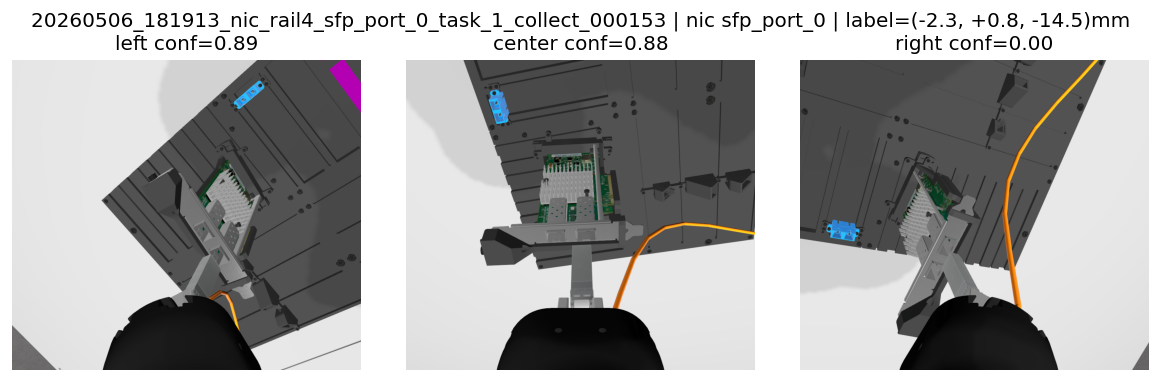

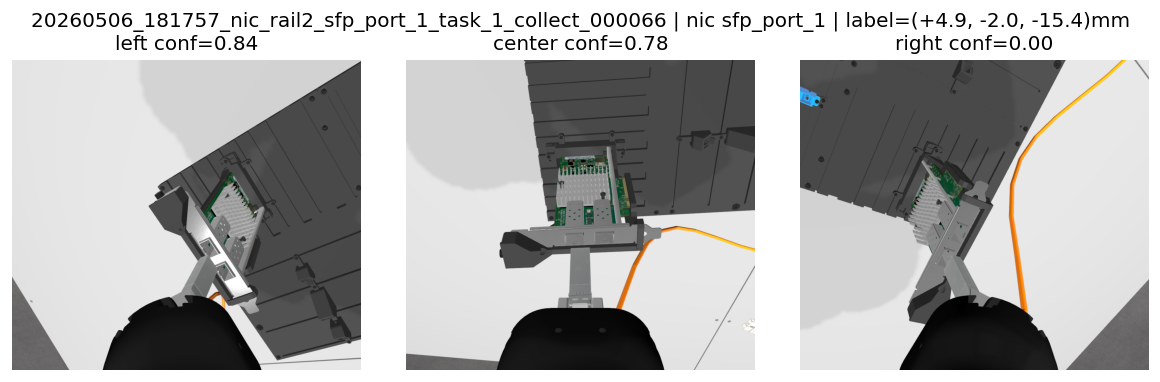

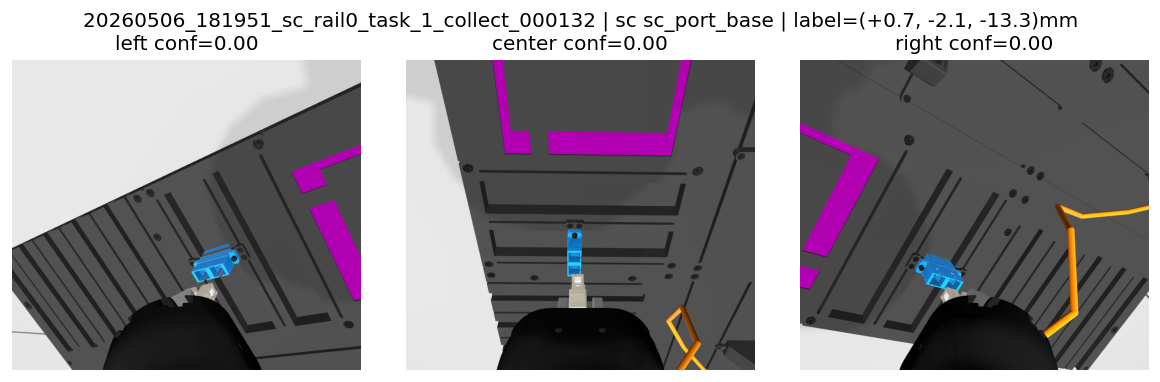

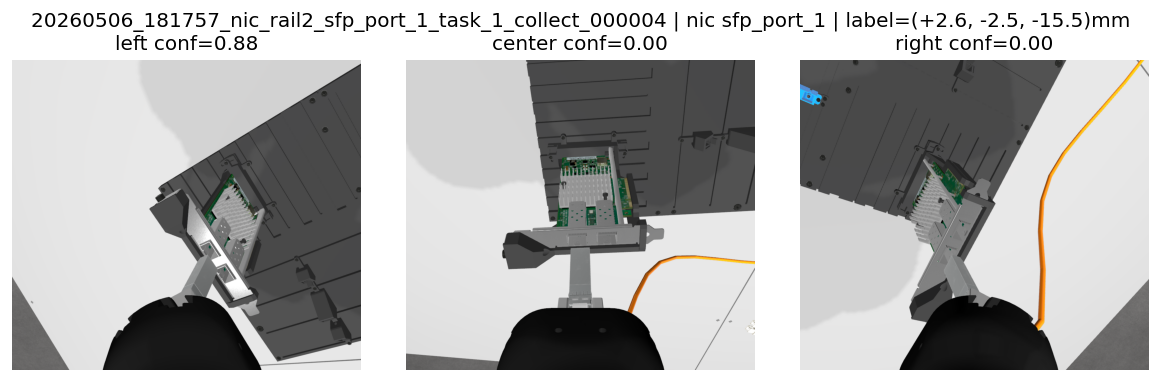

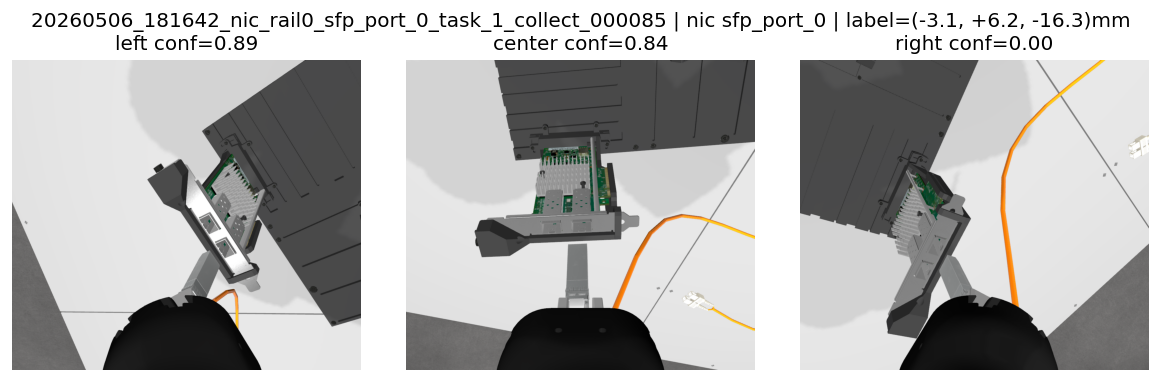

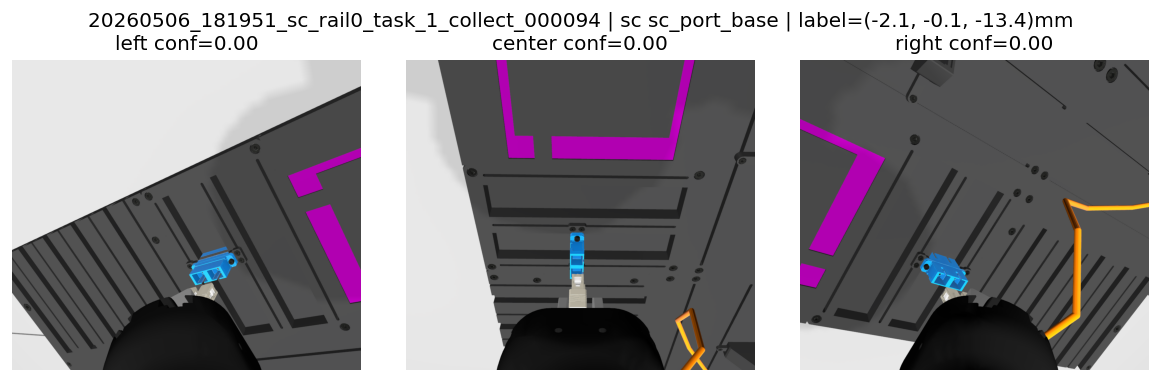

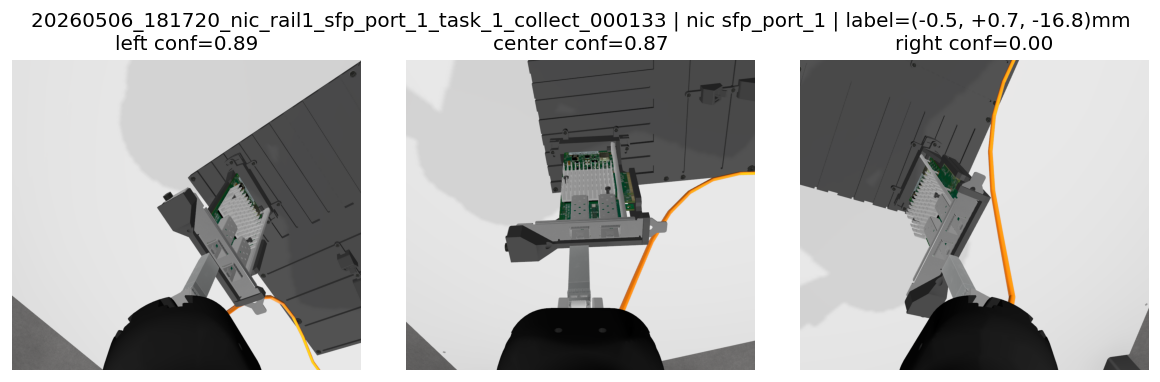

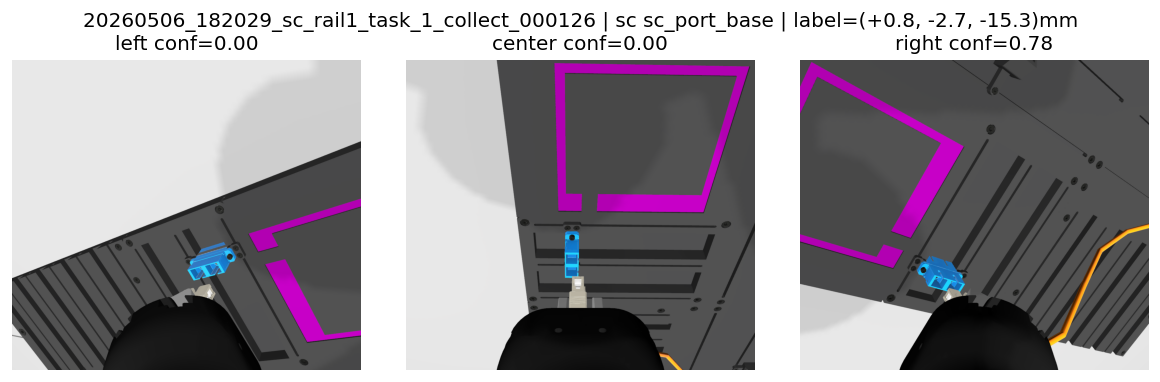

In [24]:
# 이미지 preview: 같은 sample의 left/center/right를 나란히 확인
import cv2

PREVIEW_N = int(os.environ.get('AIC_EDA_PREVIEW_N', '8'))
preview_df = df.sample(min(PREVIEW_N, len(df)), random_state=3) if len(df) else df

for _, row in preview_df.iterrows():
    fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
    for ax, cam in zip(axes, ['left', 'center', 'right']):
        rel = row[f'{cam}_image']
        path = VISION_DATASET_DIR / rel if rel else None
        if path and path.exists():
            img = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            title = f"{cam} conf={row[f'{cam}_confidence']:.2f}"
        else:
            ax.imshow(np.zeros((256, 288, 3), dtype=np.uint8))
            title = f'{cam} missing'
        ax.set_title(title)
        ax.axis('off')
    fig.suptitle(
        f"{row['sample_id']} | {row['task_type']} {row['port_name']} | "
        f"label=({row['x_mm']:+.1f}, {row['y_mm']:+.1f}, {row['z_mm']:+.1f})mm"
    )
    plt.tight_layout()
    plt.show()


In [25]:
# 학습용 flat CSV도 저장해 둔다. 이미지 path + x/y/z label 중심.
train_cols = [
    'sample_id', 'episode_name', 'task_type', 'port_name', 'target_module_name',
    'left_image', 'center_image', 'right_image',
    'x_m', 'y_m', 'z_m', 'xy_m', 'x_mm', 'y_mm', 'z_mm', 'xy_mm',
    'collect_pattern', 'collect_local_x_mm', 'collect_local_y_mm', 'collect_radius_mm',
    'left_confidence', 'center_confidence', 'right_confidence',
    'yolo_multiview_detect_count', 'triangulation_valid',
]
train_df = df[[c for c in train_cols if c in df.columns]].copy()
train_df.to_csv(OUT_DIR / 'vision_offset_flat_samples.csv', index=False)
print('Saved:', OUT_DIR / 'vision_offset_flat_samples.csv')


Saved: /home/vsc/LLM_TUNE/AIC_Sejong/ws_aic/src/ais/ais_eda/eda_outputs/vision_offset_dataset/vision_offset_flat_samples.csv
